# 7. 트리 모델, 앙상블과 차원 축소

- 목표: 결정트리, 랜덤포레스트, 부스팅, PCA, LDA를 묶어 모델 확장 감각을 기릅니다.
- 흐름: 자전거 수요 예측 베이스라인으로 회귀 프로젝트 흐름을 확인합니다.


# 결정 트리와 앙상블 기법

**결정 트리와 앙상블 기법**은 머신러닝에서 가장 널리 쓰이는 알고리즘 중 하나입니다.  
- **결정 트리(Decision Tree)**: 구조가 직관적이고 시각화가 쉬워 해석 가능성이 높음. 그러나 단독으로는 과적합 위험이 크고 성능이 제한적일 수 있음.  
- **앙상블 기법(Ensemble Methods)**: 여러 개의 모델을 결합하여 단일 모델보다 더 좋은 성능을 발휘. 특히 배깅(Bagging)과 부스팅(Boosting)이 대표적.  

👉 이 토픽에서는 **결정 트리 기본기**부터 **랜덤 포레스트, 부스팅(XGBoost 포함)** 까지 학습하여, 복잡한 데이터셋에서도 효과적인 모델을 구축할 수 있도록 합니다.  

학습 목표

- 결정 트리의 기본 개념과 작동 방식을 이해하고 설명할 수 있다.  
- 앙상블 기법의 원리를 이해하고 실제 데이터에 적용할 수 있다.  
- 결정 트리 및 앙상블 모델을 학습·평가하고, 성능을 비교할 수 있다. 

## 1. 들어가기

머신러닝 모델 중에는 복잡하지만 해석하기 어려운 모델(예: 신경망)과  
단순하지만 이해하기 쉬운 모델(예: 선형 회귀)이 있습니다.  

👉 **결정 트리(Decision Tree)** 는 그 중간에 위치합니다.  
- 데이터의 규칙을 "나무(tree)" 구조로 표현  
- 사람이 이해하기 쉽고, 시각화 가능  
- 그러나 깊게 만들면 과적합이 쉽게 발생  

  <img src="image/Decision Tree.webp" width="500">

이미지 출처 : https://www.displayr.com/what-is-a-decision-tree/

이번 장에서는 **결정 트리의 기본 개념**부터 실습까지 다룹니다.


## 2. 결정 트리 (Decision Tree)

### 2.1 기본 개념
- 데이터를 분할하여 예측하는 알고리즘  
- 트리 구조:  
  - **루트 노드(root)**: 시작점  
  - **분기 노드(split node)**: 질문을 던지는 부분 (예: 나이 > 30?)  
  - **리프 노드(leaf node)**: 최종 예측 결과 (예: 생존 / 사망)  

  <img src="image/tree_arch.webp">  
  
  이미지 출처 : https://medium.com/@ryassminh/math-for-ml-understand-regression-decision-trees-with-simple-examples-9474fceb6802


### 2.2 작동 방식
1. 데이터를 가장 잘 나누는 기준(feature, 조건)을 선택  
2. 해당 조건으로 분할  
3. 각 분할된 그룹에 대해 다시 같은 과정을 반복  
4. 더 이상 나눌 수 없을 때 예측 결과 결정  

👉 즉, "질문을 반복하면서 최종 답을 찾는 과정"


### 2.3 분할 기준

결정 트리(Decision Tree)는 데이터를 나눌 때 **불순도(impurity)** 를 줄이는 방향으로 작동합니다.  
즉, 노드를 분할했을 때 데이터가 더 “순수(pure)”해지도록 기준을 정하는 것입니다.  


####  불순도(Impurity)란?
- **불순도 = 섞여 있는 정도**
- 한 노드에 클래스가 여러 개 뒤섞여 있으면 **불순도↑**
- 한 노드에 모두 같은 클래스만 있으면 **불순도=0 (완전 순수)**

  $$
  G(p) = 1 - \sum_{i=1}^k p_i^2
  $$
  
#### 예시: 남/여 구분

어떤 데이터셋이 있고, 트리가 사람의 성별(남자/여자)을 맞추는 문제라고 해봅시다.

####  루트 노드 (처음 상태)
- 데이터: 총 10명  
  - 남자(Male) = 5명  
  - 여자(Female) = 5명  

- 지니 불순도 계산:
  $$
  G = 1 - (p_{male}^2 + p_{female}^2) 
  = 1 - (0.5^2 + 0.5^2) 
  = 1 - (0.25+0.25) = 0.5
  $$
  → 완전히 섞여 있음 (불순도 최대)


####  분할 1: “머리 길이” 기준으로 나누기
- **긴 머리 그룹**: 여자 4명, 남자 1명  
  $$
  G = 1 - (0.8^2 + 0.2^2) 
  = 1 - (0.64+0.04) = 0.32
  $$

- **짧은 머리 그룹**: 남자 4명, 여자 1명  
  $$
  G = 1 - (0.8^2 + 0.2^2) = 0.32
  $$

👉 분할 후 평균 지니 불순도:
$$
G_{avg} = \frac{5}{10}\times 0.32 + \frac{5}{10}\times 0.32 = 0.32
$$

→ 루트에서 0.5였던 불순도가 0.32로 **줄어듦** → 좋은 분할!


####  분할 2: “키” 기준으로 나누기
- **키 ≥ 170cm 그룹**: 남자 3명, 여자 2명  
  $$
  G = 1 - (0.6^2 + 0.4^2) = 1 - (0.36+0.16) = 0.48
  $$
- **키 < 170cm 그룹**: 남자 2명, 여자 3명  
  $$
  G = 1 - (0.4^2 + 0.6^2) = 0.48
  $$

👉 분할 후 평균 지니 불순도:
$$
G_{avg} = 0.48
$$

→ 루트에서 0.5였던 불순도가 0.48로 **거의 줄지 않음** → 나쁜 분할.


#### 🔹 자동으로 분할 기준 선택
- 사람이 `170cm일까, 180cm일까?`라고 임의로 정하는 게 아니라,  
- **트리 알고리즘이 모든 feature와 가능한 분할 기준(threshold)** 을 시도해봅니다.  
  - 연속형 변수(키, 나이, 수입): 가능한 분할점 후보를 전부 계산 → 불순도 감소량이 최대인 기준 선택  
  - 범주형 변수(성별, 지역): 가능한 조합을 모두 시도 → 불순도 감소량이 최대인 조합 선택  
- 결과적으로 “불순도를 가장 크게 줄여주는 기준”이 자동으로 선택됩니다.


### ✅ 정리
- 트리는 **여러 후보 특성(feature)** 중에서  
  **불순도를 가장 크게 줄이는 기준**을 스스로 선택해 데이터를 나눕니다.
- 예제에서는 “머리 길이”가 “키”보다 훨씬 좋은 분할 기준.


### 💡 직관적 비유
- 반 친구들을 남/여로 정확히 나누고 싶다.  
- **키 기준**으로 나누면 섞임이 여전히 많음 → 불순도 높음.  
- **머리 길이 기준**으로 나누면 각 그룹이 한쪽 성별로 치우침 → 불순도 낮음.  
- 따라서 트리는 “머리 길이”를 자동으로 최적 기준으로 선택.


### 1) 엔트로피(Entropy)
- 데이터의 **무질서 정도**를 측정
- 공식:
  $$
  H(p) = - \sum p \log_2 p
  $$
  여기서 \(p\)는 특정 클래스에 속할 확률

- 👉 값 해석:
  - 클래스가 섞여 있을수록 엔트로피 ↑ (최대 = 1)
  - 한쪽 클래스만 있으면 엔트로피 = 0

| 예시 (두 클래스 비율) | 엔트로피 값 |
|-------------------|-----------|
| (0, 1) → 한쪽만 존재 | 0 |
| (0.5, 0.5) → 반반   | 1 (최대 무질서) |
| (0.8, 0.2)         | 0.72 |

### 2) 지니 불순도(Gini Impurity)
- 무작위로 두 샘플을 뽑았을 때 **서로 다른 클래스일 확률**
- 공식:
  $$
  G(p) = 1 - \sum_{i=1}^k p_i^2
  $$

- $(k$): 클래스의 개수  
- $(p_i$): 현재 노드에서 클래스 $(i$)에 속할 확률 (샘플 비율)

### 🔹 유도 과정 (직관)
1. 어떤 노드에 클래스 A, B가 있다고 가정
   - 클래스 A 비율 = $(p_A$)  
   - 클래스 B 비율 = $(p_B$)  
   - (조건: $(p_A + p_B = 1$))

2. 무작위로 두 샘플을 뽑았을 때 **같은 클래스일 확률**은?  
   - 둘 다 A일 확률: $(p_A \times p_A = p_A^2$)  
   - 둘 다 B일 확률: $(p_B \times p_B = p_B^2$)  
   - 따라서 "같은 클래스일 확률" = $(p_A^2 + p_B^2$)

3. "서로 다른 클래스일 확률" = $(1 - (p_A^2 + p_B^2)$)  
   → 이것이 바로 **지니 불순도** 공식!


### 🔹 예시 (2클래스)
- (0.5, 0.5):  
  $(G = 1 - (0.5^2 + 0.5^2) = 1 - (0.25+0.25) = 0.5$)  
  → 가장 섞여 있음 (불순도 최대)

- (0.8, 0.2):  
  $(G = 1 - (0.64 + 0.04) = 0.32$)  
  → 다소 순수해짐

- (1.0, 0.0):  
  $(G = 1 - (1^2 + 0^2) = 0$)  
  → 완전히 순수


### 🔹 특징
- 범위: 0 ~ 0.5 (2클래스일 때)  
- 클래스가 많아질수록 최대값은 1에 가까워짐 (더 섞일 수 있으므로)  
- **작을수록 순수** → 결정 트리는 Gini가 줄어드는 방향으로 분할을 선택

- 👉 값 해석:
  - 클래스가 섞일수록 지니 ↑ (최대 = 0.5 for 2클래스)
  - 한쪽 클래스만 있으면 지니 = 0

| 예시 (두 클래스 비율) | 지니 값 |
|-------------------|--------|
| (0, 1)            | 0 |
| (0.5, 0.5)        | 0.5 (최대) |
| (0.8, 0.2)        | 0.32 |

### 엔트로피 vs 지니 비교
- 둘 다 **데이터 분할의 불순도**를 측정
- **공통점**: 한쪽으로 치우칠수록 값 ↓, 섞일수록 값 ↑
- **차이점**:
  - 엔트로피: 로그 계산 → 이론적 의미(정보량) 강조
  - 지니: 계산 단순, 조금 더 빠름
- 실제 성능 차이는 크지 않음 (둘 다 많이 사용)


### 직관적 비유
- 반에서 학생들이 "사과팀"과 "바나나팀"으로 나뉜다고 하자.
- **한 반에 모두 사과팀만 있다** → 완전히 순수, 불순도=0
- **사과팀/바나나팀이 반반** → 가장 섞여 있음, 불순도 최대
- 결정 트리는 이런 불순도를 줄이는 쪽으로 반을 나누어감.

### 2.4 Scikit-learn으로 결정 트리 분류기 만들기


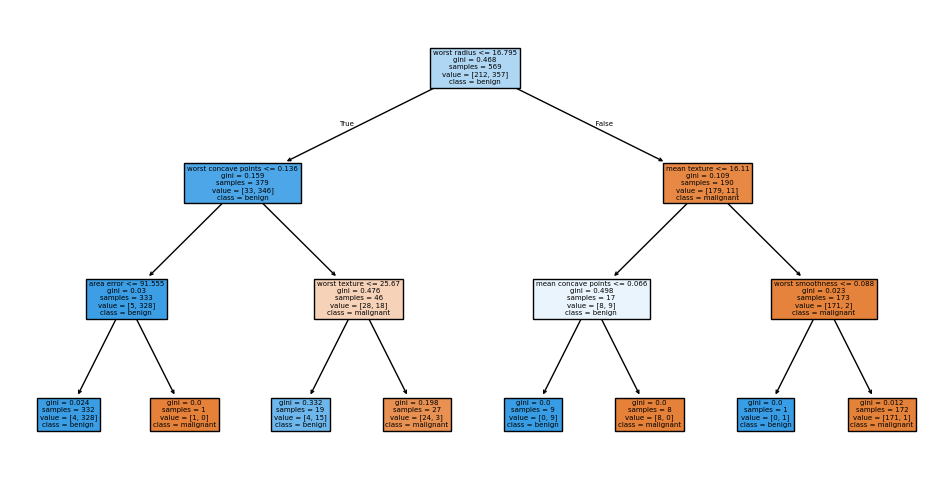

In [6]:
from sklearn.datasets import load_breast_cancer  # 사이킷런 도구를 불러옵니다.
from sklearn.tree import DecisionTreeClassifier, plot_tree  # 결정트리 분류 모델, 트리 구조 시각화 함수입니다.
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.

# 데이터 불러오기
data = load_breast_cancer()
X, y = data.data, data.target

# 결정 트리 모델 학습
model = DecisionTreeClassifier(max_depth=3, random_state=42)  # 결정트리입니다. max_depth는 깊이, random_state는 재현용입니다.
model.fit(X, y)  # 데이터로 모델이나 변환 기준을 학습합니다.

# 트리 시각화
plt.figure(figsize=(12, 6))  # 그래프 크기와 도화지를 설정합니다.
plot_tree(model, feature_names=data.feature_names, class_names=data.target_names, filled=True)  # 결정트리 구조를 그림으로 표시합니다.
plt.show()  # 그래프를 화면에 출력합니다.

### 2.5 가지치기 (Pruning)
- 트리가 너무 깊어지면 훈련 데이터에 과적합됨  
- 해결 방법:  
  - `max_depth`: 트리의 최대 깊이 제한  
  - `min_samples_split`: 분할하기 위한 최소 샘플 수  
  - `min_samples_leaf`: 리프 노드에 필요한 최소 샘플 수  
  
  <img src="image/Prune.png">  

  이미지 출처 : https://developers.google.com/machine-learning/decision-forests/overfitting-and-pruning?hl=ko

### ✅ 체크포인트
- 결정 트리는 데이터를 조건으로 분할하는 알고리즘이다.  
- 분할 기준으로는 엔트로피와 지니 불순도가 사용된다.  
- 트리가 너무 깊으면 과적합되므로 가지치기로 제어해야 한다.  
- Scikit-learn을 사용하면 결정 트리 모델을 손쉽게 구현할 수 있다.  


## 3. 앙상블 기법 (Ensemble Methods)

### 3.1 앙상블 기법이란?
- 단일 모델 하나보다, 여러 개의 모델을 결합하면 더 좋은 성능을 낼 수 있습니다.  
- 이를 **앙상블(ensemble)** 기법이라고 합니다.  
- 아이디어: "여러 사람이 투표하면 더 정확한 답을 얻을 수 있다."  


### 3.2 배깅 (Bagging: Bootstrap Aggregating)
- 데이터 샘플을 여러 번 복원추출(bootstrap) 각각의 모델을 학습시킴  
- 모든 모델의 예측을 `평균(회귀)` 또는 `다수결(분류)`로 결합  
- 분산(Variance)을 줄이고, 과적합 위험을 완화  

👉 대표적인 배깅 기법: **랜덤 포레스트(Random Forest)**  


### 3.3 랜덤 포레스트 (Random Forest)
- 여러 개의 **결정 트리(Decision Tree)** 를 학습시킨 뒤,  
  예측을 모아 최종 결과를 결정하는 알고리즘  
- 각 트리는 데이터와 특성을 랜덤하게 선택 → 다양성을 확보  
- 장점:  
  - 단일 결정 트리보다 과적합 위험이 낮음  
  - 속성 중요도(Feature Importance)를 제공


### 3.4 Scikit-learn으로 랜덤 포레스트 실습


In [7]:
from sklearn.datasets import load_breast_cancer  # 사이킷런 도구를 불러옵니다.
from sklearn.ensemble import RandomForestClassifier  # 랜덤포레스트 분류 모델입니다.
from sklearn.model_selection import train_test_split  # 훈련/평가 데이터 분리 함수입니다.
from sklearn.metrics import accuracy_score  # 정확도 지표 함수입니다.

# 데이터 불러오기
data = load_breast_cancer()
X, y = data.data, data.target

# 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 데이터를 훈련/평가용으로 나눕니다.

# 랜덤 포레스트 모델 학습
rf = RandomForestClassifier(n_estimators=100, random_state=42)  # 랜덤포레스트입니다. n_estimators는 트리 수입니다.
rf.fit(X_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.

# 예측 및 평가
y_pred = rf.predict(X_test)  # 학습한 모델로 새 값을 예측합니다.
print("정확도:", accuracy_score(y_test, y_pred))  # 정확도 비율을 계산합니다.

# 속성 중요도 출력
import pandas as pd  # 표 형태 데이터를 다루는 라이브러리입니다.
feature_importances = pd.Series(rf.feature_importances_, index=data.feature_names)  # 인덱스가 있는 1차원 데이터를 만듭니다.
print(feature_importances.sort_values(ascending=False).head(10))  # 값 기준으로 정렬합니다.

정확도: 0.9649122807017544
worst area              0.153892
worst concave points    0.144663
mean concave points     0.106210
worst radius            0.077987
mean concavity          0.068001
worst perimeter         0.067115
mean perimeter          0.053270
mean radius             0.048703
mean area               0.047555
worst concavity         0.031802
dtype: float64


### 3.5 랜덤 포레스트의 장점과 한계
- **장점**  
  - 단일 결정 트리보다 일반화 성능이 높음  
  - 다양한 데이터셋에서 안정적인 성능  
  - 속성 중요도를 통해 해석 가능  

- **한계**  
  - 단일 트리에 비해 학습 속도가 느릴 수 있음  
  - 매우 많은 트리를 사용할 경우 계산량 증가  
  - 최신 알고리즘에 비해 예측 성능이 떨어짐

### ✅ 체크포인트
- 배깅은 데이터를 여러 번 샘플링하여 여러 모델을 학습시키는 방법이다.  
- 랜덤 포레스트는 여러 결정 트리를 조합한 대표적인 배깅 기법이다.  
- 랜덤 포레스트는 과적합 위험을 줄이고, 안정적이고 강력한 성능을 제공한다.  
- 속성 중요도를 통해 어떤 변수가 중요한지 확인할 수 있다.  


## 4. 부스팅 (Boosting)

### 4.1 부스팅 개념
- 배깅과 달리, **순차적으로 모델을 학습**시키는 방법  
- 각 단계에서 **이전 모델이 틀린 데이터를 더 잘 맞추도록** 다음 모델이 학습  
- 즉, **이전 모델의 오차(error)** 를 점점 줄여가며 전체 성능을 향상  
- 약한 학습기(Weak Learner) 여러 개를 **가중합(weighted sum)** 형태로 결합해  
  강한 학습기(Strong Learner)를 만든다  
- 대표 알고리즘: **Gradient Boosting, AdaBoost, XGBoost**

**데이터는 복원추출하지 않음**  
→ 모든 학습 단계에서 전체 데이터를 사용하지만, 각 샘플에 **가중치(weight)** 를 달리 부여하여  
**이전 모델이 잘못 예측한 샘플에 더 집중**



### 4.2 Gradient Boosting
- 기본 아이디어:  
  1. 초기 예측값(단순 평균)으로 시작  
  2. 모델이 틀린 부분(잔차, residual)을 계산 
  3. 이 잔차를 줄이는 방향으로 **새로운 트리(약한 모델)** 추가 
  4. 각 단계에서 **작은 학습률(learning rate)** 을 곱해 조금씩 보정  

👉 장점: 높은 정확도  
👉 단점: 순차 학습이라 학습 속도가 느림


$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$ 

- $F_m(x)$: m번째까지의 전체 모델  
- $h_m(x)$: 새로 추가되는 약한 모델  
- $\eta$: 학습률(learning rate) → 보정 강도를 조절


### 정리  

배깅(Bagging)은 여러 모델을 **독립적으로 병렬 학습**시켜  
결과를 평균(또는 다수결)하는 방식으로 **분산(Variance)** 을 줄이는 기법이고,  
 
부스팅(Boosting)은 모델을 **순차적으로 학습**시켜 **앞선 모델의 오차를 다음 모델이 보정**하도록  
만들어 **편향(Bias)** 을 줄이는 기법입니다.  

👉 배깅은 “다양성으로 안정화”,  
👉 부스팅은 “오차 보정으로 정밀화”를 노립니다.

In [8]:
### Gradient Boosting 실습 (scikit-learn)

from sklearn.ensemble import GradientBoostingClassifier  # 그래디언트 부스팅 분류 모델입니다.
from sklearn.model_selection import train_test_split  # 훈련/평가 데이터 분리 함수입니다.
from sklearn.metrics import accuracy_score  # 정확도 지표 함수입니다.
from sklearn.datasets import load_breast_cancer  # 사이킷런 도구를 불러옵니다.

# 데이터
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 데이터를 훈련/평가용으로 나눕니다.

# 모델 학습
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)  # 부스팅 모델입니다. learning_rate는 보폭입니다.
gb.fit(X_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.

# 예측 및 평가
y_pred = gb.predict(X_test)  # 학습한 모델로 새 값을 예측합니다.
print("Gradient Boosting 정확도:", accuracy_score(y_test, y_pred))  # 정확도 비율을 계산합니다.

Gradient Boosting 정확도: 0.956140350877193


### 4.3 XGBoost
- Gradient Boosting을 최적화한 라이브러리  
- 장점:  
  - 더 빠른 학습 속도  
  - 정규화(L1, L2) 지원 → 과적합 방지  
  - 대규모 데이터에서도 효율적  
- Kaggle 대회에서 자주 사용되는 강력한 알고리즘 


In [9]:
### XGBoost 실습

import xgboost as xgb  # XGBoost 모델 라이브러리입니다.
from xgboost import XGBClassifier  # XGBoost 분류 모델입니다.

# 모델 학습
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, use_label_encoder=False, eval_metric="logloss")  # XGBoost 모델입니다. 트리 수와 학습률을 정합니다.
xgb_model.fit(X_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.

# 예측 및 평가
y_pred = xgb_model.predict(X_test)  # 학습한 모델로 새 값을 예측합니다.
print("XGBoost 정확도:", accuracy_score(y_test, y_pred))  # 정확도 비율을 계산합니다.

/home/minsu/miniconda3/envs/py310/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:38:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost 정확도: 0.956140350877193


### 4.4 Gradient Boosting vs XGBoost
- **Gradient Boosting**: 구현이 단순, 기본적인 부스팅 개념 학습에 적합  
- **XGBoost**: 속도와 성능이 뛰어나 실무 및 대규모 데이터셋에 적합  


### ✅ 체크포인트
- 부스팅은 모델을 순차적으로 학습시켜 오차를 줄이는 방식이다.  
- Gradient Boosting은 기본적인 부스팅 알고리즘이다.  
- XGBoost는 Gradient Boosting을 개선하여 속도와 성능을 강화한 알고리즘이다.  
- 학습률과 트리 개수는 부스팅 알고리즘에서 중요한 하이퍼파라미터이다.  


## 5. 모델 평가와 비교



### 5.1 왜 모델 평가가 중요한가?
- 단일 성능 지표만 보면 과적합을 놓치기 쉽습니다.  
- 훈련 데이터뿐 아니라 **검증 데이터, 교차 검증 결과**로 모델을 평가해야 합니다.  
- 특히 **결정 트리 vs 랜덤 포레스트 vs 부스팅(XGBoost)** 모델의 차이를 비교할 수 있어야 합니다.  



### 5.2 교차 검증 (Cross Validation)
- 데이터를 여러 폴드로 나눠 학습과 평가를 반복 → 평균 성능 확인  
- 안정적이고 일반화된 성능 평가 가능


In [10]:
from sklearn.model_selection import cross_val_score  # 교차검증 점수 함수입니다.
from sklearn.tree import DecisionTreeClassifier  # 결정트리 분류 모델입니다.
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # 랜덤포레스트 분류 모델, 그래디언트 부스팅 분류 모델입니다.
import xgboost as xgb  # XGBoost 모델 라이브러리입니다.
import numpy as np  # 배열과 수치 연산 라이브러리입니다.

# 모델 정의
dt = DecisionTreeClassifier(max_depth=3, random_state=42)  # 결정트리입니다. max_depth는 깊이, random_state는 재현용입니다.
rf = RandomForestClassifier(n_estimators=100, random_state=42)  # 랜덤포레스트입니다. n_estimators는 트리 수입니다.
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)  # 부스팅 모델입니다. learning_rate는 보폭입니다.
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric="logloss")  # XGBoost 모델입니다. 트리 수와 학습률을 정합니다.

models = {"Decision Tree": dt, "Random Forest": rf, "Gradient Boosting": gb, "XGBoost": xgb_model}

# 교차 검증
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)  # 교차검증 점수를 계산합니다.
    print(f"{name} 평균 정확도: {np.mean(scores):.4f}")  # 평균을 계산합니다.

Decision Tree 평균 정확도: 0.9191
Random Forest 평균 정확도: 0.9561
Gradient Boosting 평균 정확도: 0.9631


/home/minsu/miniconda3/envs/py310/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:39:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/minsu/miniconda3/envs/py310/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:39:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/minsu/miniconda3/envs/py310/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:39:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/minsu/miniconda3/envs/py310/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:40:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update

XGBoost 평균 정확도: 0.9684


### 5.3 과적합 확인
- **결정 트리**: 깊이가 깊어질수록 과적합 위험 ↑  
- **랜덤 포레스트**: 과적합 방지 효과 ↑  
- **부스팅(XGBoost)**: 높은 성능, 그러나 과적합 가능 → 학습률과 트리 수 조정 필요  

👉 해결책:  
- 교차 검증으로 안정적 평가  
- `max_depth`, `n_estimators`, `learning_rate` 등 하이퍼파라미터 조정  



### 5.4 성능 비교 예시 출력
- 보통 결과는 다음과 같이 나올 수 있음 (데이터셋에 따라 다름)  

| 모델               | 평균 정확도 |
|--|-|
| Decision Tree      | 0.90        |
| Random Forest      | 0.95        |
| Gradient Boosting  | 0.96        |
| XGBoost            | 0.97        |



### ✅ 체크포인트
- 모델은 반드시 교차 검증으로 평가해야 한다.  
- 결정 트리는 과적합되기 쉬운 반면, 랜덤 포레스트와 부스팅은 일반화 성능이 더 높다.  
- XGBoost는 대규모 데이터셋에서 뛰어난 성능을 보인다.  
- 하이퍼파라미터 튜닝을 통해 성능을 추가로 개선할 수 있다.  


### 결정 트리와 앙상블 기법 – 실습 문제

### 문제 1. 결정 트리 학습 및 시각화
Breast Cancer 데이터셋을 불러와서,  
`max_depth=3`인 결정 트리를 학습하고 시각화하세요.  

<details>
<summary>정답 보기</summary>

```python
# 풀이 흐름: 먼저 필요한 값을 계산합니다.
# 계산 결과를 표나 그래프로 확인합니다.

from sklearn.datasets import load_breast_cancer  # 실습용 유방암 데이터를 불러오는 함수입니다.
from sklearn.tree import DecisionTreeClassifier, plot_tree  # 결정 트리 모델과 트리 시각화 함수입니다.
import matplotlib.pyplot as plt  # 그래프를 그리기 위한 Matplotlib입니다.

data = load_breast_cancer()  # 예제 데이터셋을 불러옵니다.
X, y = data.data, data.target  # 모델에 넣을 입력 데이터입니다.

model = DecisionTreeClassifier(max_depth=3, random_state=42)  # 결정트리입니다. max_depth는 깊이, random_state는 재현용입니다.
model.fit(X, y)  # 데이터로 모델이나 변환 기준을 학습합니다.

plt.figure(figsize=(12,6))  # 그래프 크기와 도화지를 설정합니다.
plot_tree(model, feature_names=data.feature_names, class_names=data.target_names, filled=True)  # 결정트리 구조를 그림으로 표시합니다.
plt.show()  # 그래프를 화면에 표시합니다.

```
</details>



In [11]:
# 여기에 정답을 작성하세요
from sklearn.datasets import load_breast_cancer  # 사이킷런 도구를 불러옵니다.
from sklearn.tree import DecisionTreeClassifier, plot_tree  # 결정트리 분류 모델, 트리 구조 시각화 함수입니다.
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.

data = load_breast_cancer()
X, y = data.data, data.target

### 문제 2. 랜덤 포레스트 학습 및 정확도 평가
Breast Cancer 데이터셋을 사용하여  
`n_estimators=100`인 랜덤 포레스트 분류기를 학습하고 테스트 정확도를 구하세요.  

<details>
<summary>정답 보기</summary>

```python
# 풀이 흐름: 필요한 값을 만들고 결과를 확인합니다.
# 문제에서 요구한 결과를 계산하고 확인합니다.

from sklearn.ensemble import RandomForestClassifier  # 여러 결정 트리를 묶는 랜덤 포레스트 모델입니다.
from sklearn.model_selection import train_test_split  # 훈련/평가 데이터를 나누는 함수입니다.
from sklearn.metrics import accuracy_score  # 정확도를 계산하는 함수입니다.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 데이터를 훈련/평가용으로 나눕니다.

rf = RandomForestClassifier(n_estimators=100, random_state=42)  # 랜덤포레스트입니다. n_estimators는 트리 수입니다.
rf.fit(X_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.

y_pred = rf.predict(X_test)  # 학습한 모델로 새 값을 예측합니다.
print("정확도:", accuracy_score(y_test, y_pred))  # 결과를 화면에 출력합니다.

```
</details>

In [12]:
# 여기에 정답을 작성하세요
from sklearn.datasets import load_breast_cancer  # 사이킷런 도구를 불러옵니다.
from sklearn.tree import DecisionTreeClassifier, plot_tree  # 결정트리 분류 모델, 트리 구조 시각화 함수입니다.
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.

data = load_breast_cancer()
X, y = data.data, data.target

### 문제 3. 속성 중요도 확인
문제 2에서 학습한 랜덤 포레스트 모델의 **상위 5개 속성 중요도**를 출력하세요.  

속성 중요도란?
- **속성(feature) 중요도**는 모델이 **예측을 할 때 각 입력 변수가 얼마나 중요한 역할을 했는지**를 나타내는 값입니다.  
- 값이 높을수록 그 특성이 **결과에 더 큰 영향을 미쳤다**는 의미입니다.  
- 트리 기반 모델(의사결정나무, 랜덤포레스트, XGBoost 등)은 학습 과정에서  
  데이터를 분할할 때 **불순도(impurity)** 를 얼마나 줄였는지를 기준으로  
  자동으로 각 특성의 중요도를 계산합니다.  

확인 방법
- 학습된 모델 객체의 속성 `feature_importances_` 를 확인하면 됩니다.  
- 이 값은 각 특성의 상대적 중요도를 나타내며,  
  합계가 1(=100%)이 되도록 정규화되어 있습니다.  

<details>
<summary>정답 보기</summary>


```python
# 풀이 흐름: 필요한 값을 만들고 결과를 확인합니다.
# 문제에서 요구한 결과를 계산하고 확인합니다.

import pandas as pd  # 표 데이터를 다루기 위한 Pandas입니다.

feature_importances = pd.Series(rf.feature_importances_, index=data.feature_names)  # 인덱스가 있는 1차원 데이터를 만듭니다.
print(feature_importances.sort_values(ascending=False).head(5))  # 결과를 화면에 출력합니다.

```
</details>



In [13]:
# 여기에 정답을 작성하세요
from sklearn.datasets import load_breast_cancer  # 사이킷런 도구를 불러옵니다.
from sklearn.tree import DecisionTreeClassifier, plot_tree  # 결정트리 분류 모델, 트리 구조 시각화 함수입니다.
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.

data = load_breast_cancer()
X, y = data.data, data.target

### 문제 4. Gradient Boosting 적용
Breast Cancer 데이터셋에서 `learning_rate=0.1`, `n_estimators=100`인  
GradientBoostingClassifier를 학습하고 정확도를 출력하세요.  

<details>
<summary>정답 보기</summary>

```python
# 풀이 흐름: 필요한 값을 만들고 결과를 확인합니다.
# 문제에서 요구한 결과를 계산하고 확인합니다.

from sklearn.ensemble import GradientBoostingClassifier  # 부스팅 방식의 앙상블 모델입니다.

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)  # 부스팅 모델입니다. learning_rate는 보폭입니다.
gb.fit(X_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.

y_pred = gb.predict(X_test)  # 학습한 모델로 새 값을 예측합니다.
print("Gradient Boosting 정확도:", accuracy_score(y_test, y_pred))  # 결과를 화면에 출력합니다.

```
</details>



In [14]:
# 여기에 정답을 작성하세요
from sklearn.datasets import load_breast_cancer  # 사이킷런 도구를 불러옵니다.
from sklearn.tree import plot_tree  # 트리 구조 시각화 함수입니다.
from sklearn.ensemble import GradientBoostingClassifier  # 그래디언트 부스팅 분류 모델입니다.
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 데이터를 훈련/평가용으로 나눕니다.

### 문제 5. XGBoost 적용 및 비교
Breast Cancer 데이터셋에서 XGBoost 모델을 학습하고,  
Gradient Boosting과 정확도를 비교하세요.  

<details>
<summary>정답 보기</summary>

```python
# 풀이 흐름: 필요한 값을 만들고 결과를 확인합니다.
# 문제에서 요구한 결과를 계산하고 확인합니다.

from xgboost import XGBClassifier  # XGBoost 분류 모델입니다.

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,  # XGBoost 모델입니다. 트리 수와 학습률을 정합니다.
                          random_state=42, use_label_encoder=False, eval_metric="logloss")  # 재현성과 평가 손실 설정입니다.
xgb_model.fit(X_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.

y_pred = xgb_model.predict(X_test)  # 학습한 모델로 새 값을 예측합니다.
print("XGBoost 정확도:", accuracy_score(y_test, y_pred))  # 결과를 화면에 출력합니다.

```
</details>

In [15]:
# 여기에 정답을 작성하세요
from sklearn.datasets import load_breast_cancer  # 사이킷런 도구를 불러옵니다.
from xgboost import XGBClassifier  # XGBoost 분류 모델입니다.
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.

data = load_breast_cancer()
X, y = data.data, data.target

### 문제 6. 교차 검증으로 모델 비교
결정 트리, 랜덤 포레스트, Gradient Boosting, XGBoost 모델을  
5겹 교차 검증하여 평균 정확도를 각각 출력하세요.  

<details>
<summary>정답 보기</summary>

```python
# 풀이 흐름: 입력 데이터와 정답 데이터를 준비합니다.
# 모델이나 변환기를 적용한 뒤 결과를 확인합니다.

from sklearn.model_selection import cross_val_score  # 교차 검증 점수를 계산하는 함수입니다.
import numpy as np  # 배열 계산을 위한 Numpy입니다.

models = {  # 비교할 모델들을 딕셔너리로 묶습니다.
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),  # 결정트리입니다. max_depth는 깊이, random_state는 재현용입니다.
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),  # 랜덤포레스트입니다. n_estimators는 트리 수입니다.
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),  # 부스팅 모델입니다. learning_rate는 보폭입니다.
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42,  # XGBoost 모델입니다. 트리 수와 학습률을 정합니다.
                              use_label_encoder=False, eval_metric="logloss")  # 라벨 인코더 경고를 끄고 로그손실로 평가합니다.
}

for name, model in models.items():  # 값을 하나씩 꺼내 반복합니다.
    scores = cross_val_score(model, X, y, cv=5)  # 이름과 점수를 저장할 딕셔너리입니다.
    print(f"{name} 평균 정확도: {np.mean(scores):.4f}")  # 결과를 화면에 출력합니다.

```
</details>



In [16]:
# 여기에 정답을 작성하세요
from sklearn.datasets import load_breast_cancer  # 사이킷런 도구를 불러옵니다.
from xgboost import XGBClassifier  # XGBoost 분류 모델입니다.
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.

data = load_breast_cancer()
X, y = data.data, data.target

### ✅ 체크포인트
- 결정 트리는 이해하기 쉽지만 과적합 위험이 크다.  
- 랜덤 포레스트는 배깅 기법으로 안정적 성능을 낸다.  
- Gradient Boosting은 잔차를 줄이며 학습하는 강력한 기법이다.  
- XGBoost는 최적화된 부스팅 알고리즘으로, 속도와 성능이 뛰어나다.  
- 교차 검증을 통해 모델의 일반화 성능을 안정적으로 비교할 수 있다.  


### Kaggle 경진대회 도전

**대회 주소 :** https://www.kaggle.com/competitions/titanic/overview

**목표 :** 전처리 방법 변경 및 모델을 최적화하여 제출 후 스코어 0.82 이상 도달

**주의사항 :** 파일 제출 횟수가 하루 10번으로 제한

**참고 :**   아래 Baseline 코드는 참고만 하시고 되도록 직접 모든 과정을 해보시길 권장드립니다.

In [18]:
# 필요한 라이브러리 임포트
import pandas as pd  # 표 형태 데이터를 다루는 라이브러리입니다.
from sklearn.model_selection import train_test_split  # 훈련/평가 데이터 분리 함수입니다.
from sklearn.ensemble import RandomForestClassifier  # 랜덤포레스트 분류 모델입니다.
from sklearn.metrics import accuracy_score, classification_report  # 정확도 지표 함수, 분류 지표 요약 함수입니다.

# 데이터 불러오기
train = pd.read_csv('titanic/train.csv')  # CSV 파일을 데이터프레임으로 읽습니다.
test = pd.read_csv('titanic/test.csv')  # CSV 파일을 데이터프레임으로 읽습니다.

# 데이터 전처리
def preprocess_data(df):
    # 결측치 처리
    df['Age'] = df['Age'].fillna(df['Age'].mean())  # 결측치를 지정한 값으로 채웁니다.
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])  # 결측치를 지정한 값으로 채웁니다.
    df['Fare'] = df['Fare'].fillna(df['Fare'].mean())  # 결측치를 지정한 값으로 채웁니다.
    
    # 범주형 변수 처리
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})  # 값을 지정한 규칙으로 바꿉니다.
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})  # 값을 지정한 규칙으로 바꿉니다.
    
    # 필요한 특성 선택
    features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
    return df[features]

# 학습 데이터 전처리
X = preprocess_data(train)
y = train['Survived']

# 학습 데이터와 검증 데이터 분리
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)  # 데이터를 훈련/평가용으로 나눕니다.

# RandomForest 모델 생성 및 학습
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # 랜덤포레스트입니다. n_estimators는 트리 수입니다.
rf_model.fit(X_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.

# 검증 데이터로 예측
val_pred = rf_model.predict(X_val)  # 학습한 모델로 새 값을 예측합니다.

# 모델 성능 평가
print('검증 데이터 정확도:', accuracy_score(y_val, val_pred))  # 정확도 비율을 계산합니다.
print('\n분류 보고서:')  # 문자열을 정수로 바꿉니다.
print(classification_report(y_val, val_pred))  # 정밀도/재현율/F1을 요약합니다.

# 테스트 데이터 예측
test_processed = preprocess_data(test)
test_pred = rf_model.predict(test_processed)  # 학습한 모델로 새 값을 예측합니다.

# 제출 파일 생성
submission = pd.DataFrame({  # 데이터프레임을 직접 만듭니다.
    'PassengerId': test['PassengerId'],
    'Survived': test_pred
})
submission.to_csv('submission.csv', index=False)
print('\n제출 파일이 생성되었습니다.')  # 문자열을 정수로 바꿉니다.


검증 데이터 정확도: 0.8212290502793296

분류 보고서:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179


제출 파일이 생성되었습니다.


# 차원 축소 (Dimensionality Reduction)

## 1. 개요

### 배경
현실 데이터는 수십, 수백 개의 특성을 가진 **고차원 데이터**인 경우가 많습니다.  
차원이 높아지면 → 시각화가 어려워지고, 계산량이 폭발하며, 모델이 과적합되는 문제가 발생합니다.  

👉 **차원 축소(Dimensionality Reduction)** 는  
- 데이터의 중요한 정보를 유지하면서,  
- 불필요하거나 중복된 차원을 줄여  
- 시각화, 처리 효율성, 모델 성능 향상에 기여합니다.

## 학습 목표
이 토픽을 수강한 뒤, 수강생은 다음을 할 수 있어야 합니다:

- 차원 축소의 필요성과 이점을 설명할 수 있다.  
- PCA와 LDA의 원리를 이해하고 실제 데이터에 적용할 수 있다.  
- 차원 축소를 통해 데이터 시각화 및 모델 성능 평가를 수행할 수 있다.

## 주요 학습 개념

- **차원 축소란?**
  - 차원 축소의 정의와 필요성  
  - 차원 축소의 이점 (시각화, 처리 효율성, 성능 향상 등)  

- **PCA (Principal Component Analysis)**  
  - PCA의 기본 개념  
  - 공분산 행렬과 고유벡터  
  - 주성분 선택 원리  
  - scikit-learn을 사용한 PCA 구현  

- **LDA (Linear Discriminant Analysis)**  
  - LDA의 기본 개념  
  - 클래스 분리 기준 (between-class variance / within-class variance)  
  - scikit-learn을 사용한 LDA 구현  

- **차원 축소 활용**  
  - 차원 축소를 통한 데이터 시각화 (2D, 3D 표현)  
  - 차원 축소 후 모델 성능 비교  
  - 차원 축소 vs 피처 선택 차이점  

## 2. 들어가기

데이터가 가진 **차원(dimension)** 이란, 하나의 데이터가 가지고 있는 **특성(feature)** 의 개수를 의미합니다.  
예:  
- 키, 몸무게, 나이 → 3차원 데이터  
- 픽셀 784개로 이루어진 MNIST 숫자 이미지 → 784차원 데이터


👉 차원이 커질수록 나타나는 문제:  
- **시각화 불가능**: 3차원 이상은 인간이 직관적으로 보기 어렵다.  
- **계산량 폭발**: 차원이 늘어나면 거리 계산, 행렬 연산이 급격히 늘어난다.  
- **차원의 저주(Curse of Dimensionality)**: 차원이 커질수록 데이터가 희소해져 모델 학습이 어려워진다.  

  <img src="image/dimensionality.png">  

이미지 출처 : https://www.visiondummy.com/2014/04/curse-dimensionality-affect-classification/#google_vignette

따라서 차원을 줄이는 기술, 즉 **차원 축소(Dimensionality Reduction)** 가 필요하다.  

## 3. 차원 축소 기본 개념

### 3.1 차원 축소란?
- 원래 데이터의 중요한 정보를 유지하면서 **특성의 개수를 줄이는 과정**  
- 불필요한 변수 제거, 데이터 압축, 시각화에 활용  

<img src="image/Dimensionality_Reduction.jpg">  

이미지 출처 : https://blog.roboflow.com/what-is-dimensionality-reduction/


### 3.2 차원 축소의 이점
1. **시각화 용이**  
   - 2D, 3D로 축소하여 데이터 패턴을 그림으로 확인 가능  
2. **처리 효율성 향상**  
   - 계산량이 줄어 모델 훈련 속도 증가  
3. **잡음 제거**  
   - 중요하지 않은 특성을 줄여 모델 성능 향상  
4. **과적합 방지**  
   - 복잡성을 줄여 일반화 성능 향상


### 3.3 차원 축소 방법
- **PCA (주성분 분석)**: 분산이 가장 큰 방향을 찾아 차원 축소  
- **LDA (선형 판별 분석)**: 클래스 간 분리를 최대화하는 방향으로 축소  
- (심화) t-SNE, UMAP: 비선형 데이터 시각화에 강력


### 3.4 간단한 예시 (Iris 데이터셋 시각화 전후)


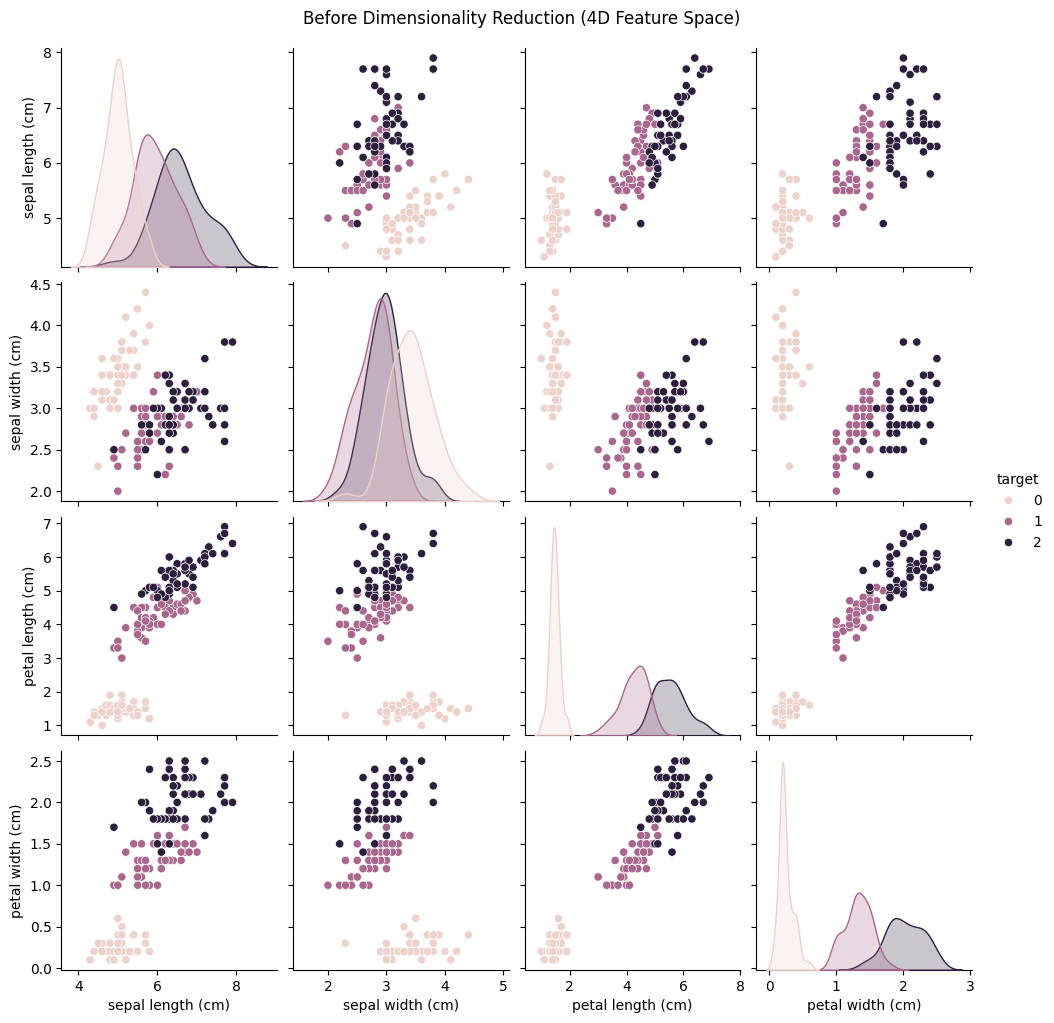

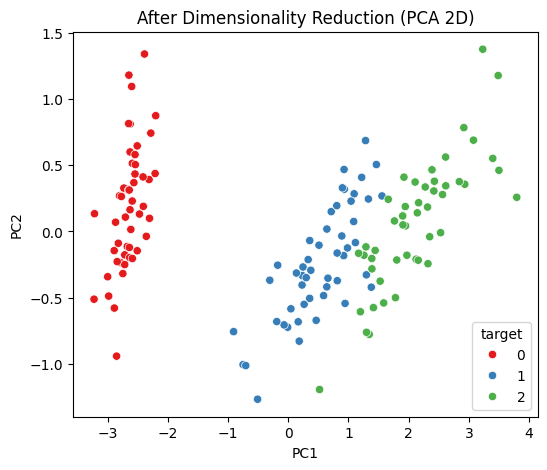

In [19]:
from sklearn.datasets import load_iris  # 사이킷런 도구를 불러옵니다.
from sklearn.decomposition import PCA  # 차원축소 도구입니다.
import pandas as pd  # 표 형태 데이터를 다루는 라이브러리입니다.
import seaborn as sns  # 통계 그래프 시각화 도구입니다.
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.
import warnings
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.
warnings.filterwarnings("ignore", category=FutureWarning) # FutureWarning 숨기기


# 데이터 불러오기
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)  # 데이터프레임을 직접 만듭니다.
df["target"] = iris.target

# ---------------------
# 전(before): 4D → pairplot
# ---------------------
sns.pairplot(df, hue="target", vars=iris.feature_names)  # 시본 그래프를 그립니다.
plt.suptitle("Before Dimensionality Reduction (4D Feature Space)", y=1.02)
plt.show()  # 그래프를 화면에 출력합니다.

# ---------------------
# 후(after): PCA → 2D
# ---------------------
pca = PCA(n_components=2)  # PCA 차원축소입니다. n_components는 줄일 차원 수입니다.
pca_result = pca.fit_transform(iris.data)  # 기준 학습과 변환을 한 번에 수행합니다.

df_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])  # 데이터프레임을 직접 만듭니다.
df_pca["target"] = iris.target

plt.figure(figsize=(6,5))  # 그래프 크기와 도화지를 설정합니다.
sns.scatterplot(x="PC1", y="PC2", hue="target", data=df_pca, palette="Set1")  # 시본 그래프를 그립니다.
plt.title("After Dimensionality Reduction (PCA 2D)")  # 그래프 제목을 설정합니다.
plt.show()  # 그래프를 화면에 출력합니다.


### ✅ 체크포인트
- 차원 = 데이터의 특성 개수  
- 차원이 높으면 계산량과 복잡성이 증가 → 차원의 저주 발생  
- 차원 축소는 시각화, 효율성, 성능 향상에 도움을 준다  
- 대표 기법: PCA, LDA (→ 다음 장에서 학습)  

## 4. PCA (Principal Component Analysis)

### 4.1 PCA란?
- **고차원 데이터를 저차원으로 축소**하는 가장 대표적인 기법  
- 데이터의 **분산(variance)** 이 가장 큰 방향을 찾아 새로운 축(주성분, Principal Component)을 만든다  
- 이렇게 만든 축을 따라 데이터를 투영하여 차원을 줄인다  

👉 핵심 아이디어:  
"데이터를 가장 잘 설명할 수 있는 방향(축)을 찾아, 그 축만 남기고 나머지는 버리자"


### 4.2 PCA 절차 (상세 설명)

#### **1. 데이터 표준화 (평균=0, 표준편차=1)**  

PCA는 **변수의 스케일(단위)** 에 매우 민감하다.  
예를 들어, 키(cm)와 몸무게(kg)를 함께 쓰면, 단위가 큰 쪽이 분산을 지배하게 된다.  
이를 방지하기 위해 **평균을 0, 표준편차를 1**로 맞추는 과정을 거친다.


#### **2. 공분산 행렬 계산 (Covariance Matrix)**  

표준화된 데이터의 변수들 간의 관계(변동 방향과 크기)를 보기 위해 **공분산행렬**을 만든다.

공분산의 정의:

$
\text{Cov}(X, Y) = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})
$

- Cov > 0 → 두 변수가 **같은 방향으로 변함**  
- Cov < 0 → 두 변수가 **반대 방향으로 변함**  
- Cov ≈ 0 → **거의 무관함**
#### **공분산행렬의 형태 예시**

2개의 변수 \(X_1, X_2\)에 대해:

$$
\Sigma =
\begin{bmatrix}
\text{Var}(X_1) & \text{Cov}(X_1, X_2) \\
\text{Cov}(X_2, X_1) & \text{Var}(X_2)
\end{bmatrix}
$$

예를 들어:
$$
\Sigma =
\begin{bmatrix}
4 & 2 \\
2 & 3
\end{bmatrix}
$$

- **대각선 원소**는 각 변수의 **분산(Var)**  -> 각 변수 축 방향으로의 퍼짐 정도
- **비대각선 원소**는 변수 간의 **공분산(Cov)** -> 어느 방향으로 함께 움직이는가
- Cov가 양수 → 두 변수가 같은 방향으로 변동  
- Cov가 음수 → 반대 방향으로 변동  
- Cov가 0에 가까움 → 두 변수가 독립적

공분산이란,  
> “각 표본이 평균으로부터 얼마나 벗어나 있는지를 곱해본 뒤,  
> 그 값이 일관되게 양수인지 음수인지 확인하는 것”  
만약 +와 −가 섞여서 상쇄되면 Cov≈0 → 상관 없음.

#### **3. 공분산 행렬의 고유벡터와 고유값 계산** 

공분산 행렬은 **데이터가 각 축 방향으로 얼마나 퍼져 있는지**와 **서로 얼마나 함께 움직이는지(상관성)** 를 담고 있다.  

이 공분산 행렬을 **고유값 분해(Eigen Decomposition)** 하면, 데이터가 실제로 **어느 방향으로 퍼져 있는지(고유벡터)** 와  
그 **퍼진 정도(고유값)** 를 수학적으로 찾아낼 수 있다.

$
\Sigma v = \lambda v
$

- $v$: 고유벡터(Eigenvector) → 데이터가 가장 퍼진 방향 (새로운 축, 주성분)  
- $\lambda$: 고유값(Eigenvalue) → 그 방향으로 퍼져 있는 정도 (분산의 크기)

즉,  
- 고유값이 **클수록** 데이터가 그 방향으로 **넓게 퍼져 있음**  
- 고유값이 **작을수록** 그 방향으로는 **거의 퍼지지 않음** 

예를 들어,  
데이터가 y=x 방향으로 길게 퍼져 있다면,  
고유벡터가 [1,1] 방향이 되고,  
그 고유값이 크다는 것은 “그 방향으로 데이터가 많이 퍼져 있다”는 의미이다.  
반대로 y=-x 방향은 데이터가 거의 없으므로 고유값이 작게 나온다.

#### **4. 고유값이 큰 순서대로 주성분 선택**  

PCA에서는 이렇게 얻은 **고유값(=분산 크기)** 을 기준으로  
데이터를 잘 설명하는 **방향(축)** 을 고른다.  

- 고유값이 **큰 축(=고유벡터)** → 데이터의 주요한 패턴이 담긴 방향  
- 고유값이 **작은 축** → 거의 의미 없는 노이즈 방향  

따라서, 고유값이 큰 순서대로 축을 정렬하면  
데이터의 분산(정보량)을 가장 잘 설명하는 **주성분(Principal Component)** 순서가 된다.

| 주성분 | 고유값(분산 비율) | 설명 |
|----------|--------------------|--------|
| PC1 | 3.2 (80%) | 데이터의 대부분 변동을 설명 |
| PC2 | 0.8 (20%) | 잔여 변동 설명 |

예를 들어, 2차원 데이터(PC1, PC2) 중 PC1이 전체 정보의 80%를 설명한다면  
차원을 2 → 1로 줄일 때 **PC1만 사용**해도 데이터의 대부분 정보를 유지할 수 있다.

#### 5. 원래 데이터를 주성분 축으로 변환

이제 원본 데이터를 우리가 찾은 **새로운 축(고유벡터)** 에 맞춰 다시 표현한다.  
이 과정을 **투영(projection)** 이라고 한다.

$ Z = X W $

- X: 표준화된 원본 데이터  
- W: 선택된 주성분 벡터들  
- Z: 변환된 데이터 (차원 축소 결과)

즉, 데이터를 기존의 x, y축 대신 “데이터가 실제로 퍼져 있는 방향(주성분 축)”으로 옮겨 표현하는 것이다.  

이렇게 하면,  
- 중복된 정보(서로 상관된 축)를 제거하고,  
- 데이터의 핵심적인 패턴만 남긴 채 **차원을 줄이게 된다.**

### 4.3 PCA 시각적 직관

2차원 데이터를 예로 들어보자.  
데이터가 다음과 같이 **대각선 방향(↗)** 으로 퍼져 있다고 가정하자.

```markdown
y ↑
  |
  |         ●
  |      ●
  |   ●
  |●
  |__________________________→ x
```

이 경우, 원래의 x·y축은 데이터의 분포를 제대로 설명하지 못한다.  
데이터가 실제로 퍼진 방향(대각선 방향)을 기준으로 보면, 데이터의 **변동성(분산)** 이 훨씬 크다.

👉 따라서, PCA는 다음과 같은 판단을 내린다.

> “데이터가 실제로 퍼진 방향이 정보(분산)를 가장 많이 담고 있으니, 그 방향을 새 축으로 삼자.”


####  PCA가 하는 일
1. 데이터의 분산이 가장 큰 방향(↗)을 찾아 **새로운 축(PC1)** 으로 설정한다.  
2. PC1에 **직교하는 방향(↘)** 을 **두 번째 축(PC2)** 으로 설정한다.  
3. 데이터를 이 두 축으로 **회전(변환)** 시켜 새 좌표계로 표현한다.  
4. 정보 손실을 최소화하기 위해 **분산이 큰 축(PC1)** 만 남기고  
   나머지 축(PC2)은 **제거(차원 축소)** 한다.


####  핵심 개념 정리

- **PC1 (첫 번째 주성분)**:  
  데이터가 가장 넓게 퍼진 방향 (분산 최대, 핵심 정보 축)

- **PC2 (두 번째 주성분)**:  
  PC1에 직교하는 방향 (잔여 변동, 미세한 노이즈)

- PCA는 데이터를 이 두 축으로 다시 표현하고,  
  정보가 많은 **PC1만 남겨** 데이터의 차원을 줄인다.


> **요약**
>  
> PCA는 “공분산행렬을 고유값분해하여,  
> 데이터의 분산이 가장 큰 방향(즉, 정보가 가장 많은 방향)을 찾아  
> 그 축으로 데이터를 재표현하고,  
> 필요에 따라 저차원으로 축소하는 기법”이다.


### 4.4 Scikit-learn으로 PCA 구현


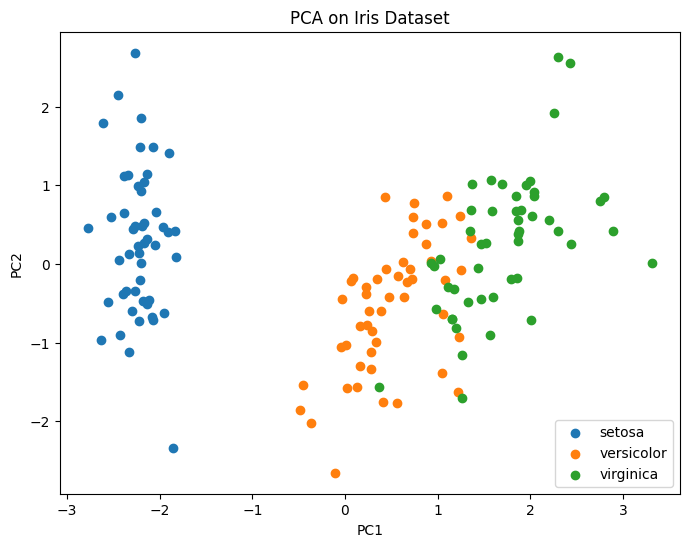

In [20]:
from sklearn.decomposition import PCA  # 차원축소 도구입니다.
from sklearn.preprocessing import StandardScaler  # 표준화 변환기입니다.
from sklearn.datasets import load_iris  # 사이킷런 도구를 불러옵니다.
import pandas as pd  # 표 형태 데이터를 다루는 라이브러리입니다.
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.

# 데이터 불러오기
iris = load_iris()
X = iris.data
y = iris.target

# 1) 데이터 표준화
X_scaled = StandardScaler().fit_transform(X)  # 표준화 변환기입니다. 평균 0, 표준편차 1로 맞춥니다.

# 2) PCA (2차원으로 축소)
pca = PCA(n_components=2)  # PCA 차원축소입니다. n_components는 줄일 차원 수입니다.
X_pca = pca.fit_transform(X_scaled)  # 기준 학습과 변환을 한 번에 수행합니다.

# 3) DataFrame 변환
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])  # 데이터프레임을 직접 만듭니다.
df_pca["target"] = y

# 4) 시각화
plt.figure(figsize=(8,6))  # 그래프 크기와 도화지를 설정합니다.
for target in set(y):
    subset = df_pca[df_pca["target"] == target]
    plt.scatter(subset["PC1"], subset["PC2"], label=iris.target_names[target])  # 산점도를 그립니다.
plt.xlabel("PC1")  # x축 이름을 설정합니다.
plt.ylabel("PC2")  # y축 이름을 설정합니다.
plt.legend()  # 범례를 표시합니다.
plt.title("PCA on Iris Dataset")  # 그래프 제목을 설정합니다.
plt.show()  # 그래프를 화면에 출력합니다.

### 4.5 주성분의 분산 설명력
PCA는 각 주성분이 원래 데이터의 분산을 얼마나 설명하는지도 알려준다.  

```python
print("주성분별 설명된 분산 비율:", pca.explained_variance_ratio_)  # 문자열을 정수로 바꿉니다.
print("설명된 총 분산 비율:", sum(pca.explained_variance_ratio_))  # 문자열을 정수로 바꿉니다.
```

👉 일반적으로, **앞 몇 개의 주성분만으로도 대부분의 정보를 유지**할 수 있다.


### ✅ 체크포인트
- PCA는 데이터의 **분산이 큰 방향**을 찾아 차원을 줄이는 기법이다.  
- 주성분은 공분산 행렬의 고유벡터로 정의된다.  
- Scikit-learn으로 손쉽게 PCA를 적용할 수 있다.  
- `explained_variance_ratio_`를 통해 정보 보존 정도를 확인할 수 있다.  


## 5. LDA (Linear Discriminant Analysis)

### 5.1 LDA란?
- **지도 학습 기반 차원 축소 기법**  
- PCA는 클래스(label)를 고려하지 않지만, **LDA는 클래스 정보를 사용**  
- 목표: 서로 다른 클래스 간 분리가 잘 되도록 새로운 축을 찾는 것  

👉 직관적으로, "클래스 간의 거리는 최대화, 클래스 내부의 분산은 최소화"  


### 5.2 LDA 절차
1. 클래스별 평균과 전체 평균 계산  
2. 클래스 간 분산(between-class scatter)과 클래스 내 분산(within-class scatter) 계산  
3. 두 분산 비율을 최대화하는 축 찾기  
4. 데이터를 그 축에 투영  


### 5.3 LDA와 PCA 차이점
- PCA: **데이터의 분산**을 가장 잘 설명하는 축 찾기 (비지도 학습)  
- LDA: **클래스 간 분리**를 가장 잘 설명하는 축 찾기 (지도 학습)  


### 5.4 Scikit-learn으로 LDA 구현


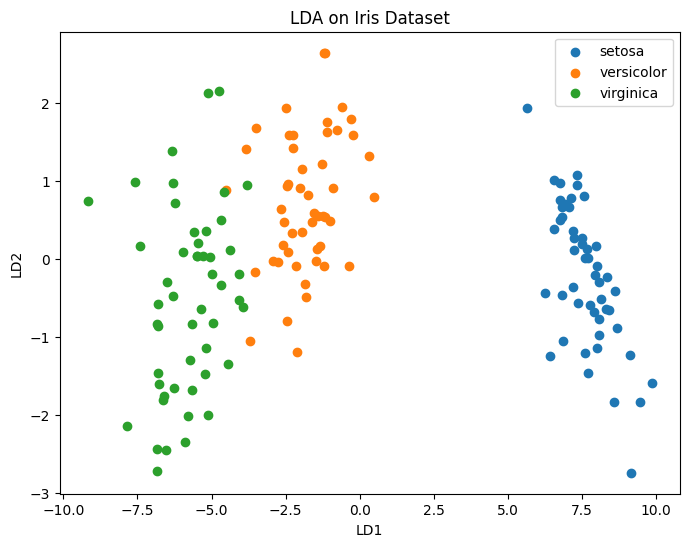

In [21]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA  # LDA 차원축소/분류 도구입니다.
from sklearn.datasets import load_iris  # 사이킷런 도구를 불러옵니다.
import pandas as pd  # 표 형태 데이터를 다루는 라이브러리입니다.
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.

# 데이터 불러오기
iris = load_iris()
X = iris.data
y = iris.target

# LDA (2차원으로 축소)
lda = LDA(n_components=2)  # LDA입니다. 라벨 정보를 활용해 차원을 줄입니다.
X_lda = lda.fit_transform(X, y)  # 기준 학습과 변환을 한 번에 수행합니다.

# DataFrame 변환
df_lda = pd.DataFrame(X_lda, columns=["LD1", "LD2"])  # 데이터프레임을 직접 만듭니다.
df_lda["target"] = y

# 시각화
plt.figure(figsize=(8,6))  # 그래프 크기와 도화지를 설정합니다.
for target in set(y):
    subset = df_lda[df_lda["target"] == target]
    plt.scatter(subset["LD1"], subset["LD2"], label=iris.target_names[target])  # 산점도를 그립니다.
plt.xlabel("LD1")  # x축 이름을 설정합니다.
plt.ylabel("LD2")  # y축 이름을 설정합니다.
plt.legend()  # 범례를 표시합니다.
plt.title("LDA on Iris Dataset")  # 그래프 제목을 설정합니다.
plt.show()  # 그래프를 화면에 출력합니다.

### 5.5 LDA의 활용
- **시각화**: 고차원 데이터를 2D/3D로 줄여 시각적으로 클래스 분포 확인  
- **분류 성능 향상**: 차원을 줄이면서도 클래스 정보를 반영하여 더 잘 분리된 데이터 생성  
- **전처리 단계**: 분류 모델 적용 전 데이터 축소


### ✅ 체크포인트
- LDA는 클래스 정보를 활용하는 지도학습 기반 차원 축소 기법이다.  
- 클래스 간 분산은 최대화, 클래스 내 분산은 최소화한다.  
- PCA와 달리 LDA는 "클래스 분리"에 초점이 있다.  
- Scikit-learn을 통해 손쉽게 LDA를 적용하고 시각화할 수 있다.  

## 6. 차원 축소 활용

### 6.1 데이터 시각화
차원 축소의 가장 직관적인 효과는 **고차원 데이터를 2D 또는 3D로 시각화**할 수 있다는 점입니다.  

예: Iris 데이터셋을 PCA와 LDA로 축소 후 시각화


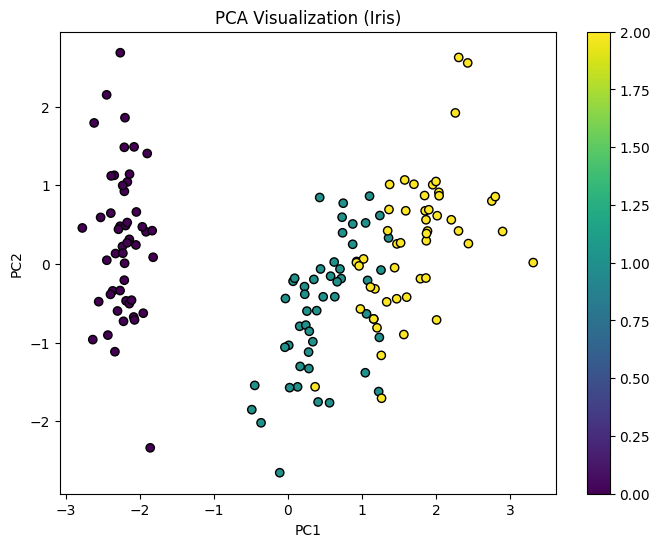

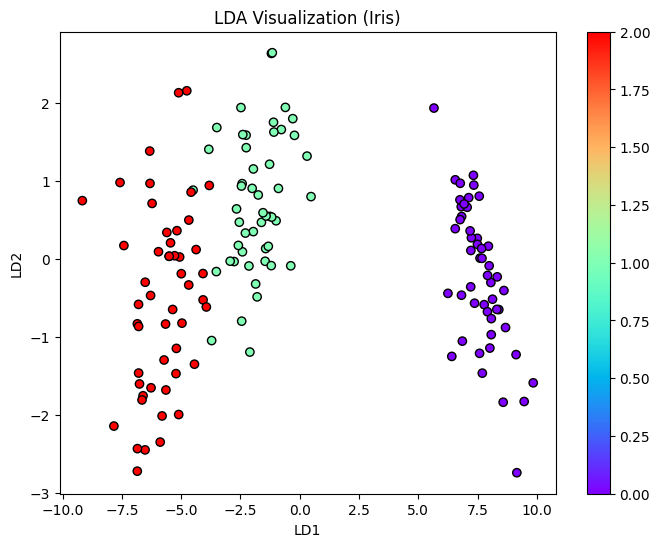

In [22]:
# 이미 PCA, LDA로 변환된 데이터 (X_pca, X_lda)
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.

# PCA 결과 시각화
plt.figure(figsize=(8,6))  # 그래프 크기와 도화지를 설정합니다.
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis", edgecolor="k")  # 산점도를 그립니다.
plt.xlabel("PC1")  # x축 이름을 설정합니다.
plt.ylabel("PC2")  # y축 이름을 설정합니다.
plt.title("PCA Visualization (Iris)")  # 그래프 제목을 설정합니다.
plt.colorbar()
plt.show()  # 그래프를 화면에 출력합니다.

# LDA 결과 시각화
plt.figure(figsize=(8,6))  # 그래프 크기와 도화지를 설정합니다.
plt.scatter(X_lda[:,0], X_lda[:,1], c=y, cmap="rainbow", edgecolor="k")  # 산점도를 그립니다.
plt.xlabel("LD1")  # x축 이름을 설정합니다.
plt.ylabel("LD2")  # y축 이름을 설정합니다.
plt.title("LDA Visualization (Iris)")  # 그래프 제목을 설정합니다.
plt.colorbar()
plt.show()  # 그래프를 화면에 출력합니다.

👉 결과:  
- PCA는 데이터의 분산을 최대한 보존 → 전체 구조 파악  
- LDA는 클래스 분리를 최적화 → 그룹이 더 명확히 구분

### 6.2 모델 성능 비교
차원 축소 후 **모델을 학습**하여 성능 차이를 비교할 수 있습니다.  


In [23]:
from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀 분류 모델입니다.
from sklearn.model_selection import train_test_split  # 훈련/평가 데이터 분리 함수입니다.
from sklearn.metrics import accuracy_score  # 정확도 지표 함수입니다.

# 데이터 분할 (원본 데이터 vs PCA 변환 데이터)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 데이터를 훈련/평가용으로 나눕니다.

# 원본 데이터
lr = LogisticRegression(max_iter=200)  # 로지스틱 회귀입니다. max_iter는 최대 반복입니다.
lr.fit(X_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.
y_pred = lr.predict(X_test)  # 학습한 모델로 새 값을 예측합니다.
print("원본 데이터 정확도:", accuracy_score(y_test, y_pred))  # 정확도 비율을 계산합니다.

# PCA 데이터
X_pca_train, X_pca_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)  # 데이터를 훈련/평가용으로 나눕니다.
lr.fit(X_pca_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.
y_pred_pca = lr.predict(X_pca_test)  # 학습한 모델로 새 값을 예측합니다.
print("PCA 데이터 정확도:", accuracy_score(y_test, y_pred_pca))  # 정확도 비율을 계산합니다.

# LDA 데이터
X_lda_train, X_lda_test, y_train, y_test = train_test_split(X_lda, y, test_size=0.2, random_state=42)  # 데이터를 훈련/평가용으로 나눕니다.
lr.fit(X_lda_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.
y_pred_lda = lr.predict(X_lda_test)  # 학습한 모델로 새 값을 예측합니다.
print("LDA 데이터 정확도:", accuracy_score(y_test, y_pred_lda))  # 정확도 비율을 계산합니다.

원본 데이터 정확도: 1.0
PCA 데이터 정확도: 0.9
LDA 데이터 정확도: 1.0


👉 보통:  
- PCA → 데이터 압축 후에도 성능 유지 또는 향상 가능  
- LDA → 클래스 분리도를 높여 분류 성능 개선 

### 6.3 피처 선택 vs 차원 축소
- **피처 선택 (Feature Selection)**  
  - 원래의 변수 중 중요한 것만 고름  
  - 해석이 쉽다 (예: “꽃받침 길이와 꽃잎 폭이 중요하다”)  

- **차원 축소 (Dimensionality Reduction)**  
  - 원래의 변수를 조합해 새로운 변수(주성분, 판별축)를 생성  
  - 해석은 어렵지만 더 효율적일 수 있다  

👉 즉, 피처 선택은 "원래 특성 중 일부만 고르기", 차원 축소는 "새로운 특성 만들기"


### ✅ 체크포인트
- 차원 축소는 데이터 시각화, 계산 효율, 성능 향상에 유용하다.  
- PCA는 분산 보존, LDA는 클래스 분리에 초점.  
- 차원 축소 후에도 모델 성능을 반드시 다시 평가해야 한다.  
- 피처 선택과 차원 축소는 다른 접근 방식이므로 구분해야 한다.

### 차원 축소 – 실습 문제

### 문제 1. PCA 변환
Iris 데이터셋을 불러와서,  
`n_components=2`인 PCA를 적용한 뒤 2차원 산점도로 시각화하세요.  

<details>
<summary>정답 보기</summary>

```python
# 풀이 흐름: 필요한 값을 만들고 결과를 확인합니다.
# 문제에서 요구한 결과를 계산하고 확인합니다.

from sklearn.decomposition import PCA  # PCA 차원 축소 도구입니다.
from sklearn.preprocessing import StandardScaler  # 평균 0, 표준편차 1로 맞추는 도구입니다.
from sklearn.datasets import load_iris  # 실습용 iris 데이터를 불러오는 함수입니다.
import matplotlib.pyplot as plt  # 그래프를 그리기 위한 Matplotlib입니다.

iris = load_iris()  # 예제 데이터셋을 불러옵니다.
X, y = iris.data, iris.target  # 모델에 넣을 입력 데이터입니다.

# 표준화
X_scaled = StandardScaler().fit_transform(X)  # 학습과 변환을 한 번에 수행합니다.

# PCA 적용
pca = PCA(n_components=2)  # PCA 차원축소입니다. n_components는 줄일 차원 수입니다.
X_pca = pca.fit_transform(X_scaled)  # 학습과 변환을 한 번에 수행합니다.

# 시각화
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis", edgecolor="k")  # 산점도를 그립니다.
plt.xlabel("PC1")  # x축 이름을 설정합니다.
plt.ylabel("PC2")  # y축 이름을 설정합니다.
plt.title("PCA on Iris")  # 그래프 제목을 설정합니다.
plt.show()  # 그래프를 화면에 표시합니다.

```
</details>



In [24]:
# 여기에 코드를 작성하세요 
from sklearn.decomposition import PCA  # 차원축소 도구입니다.
from sklearn.preprocessing import StandardScaler  # 표준화 변환기입니다.
from sklearn.datasets import load_iris  # 사이킷런 도구를 불러옵니다.
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.

# 데이터 불러오기
iris = load_iris()
X = iris.data
y = iris.target

### 문제 2. 주성분 분산 설명력
문제 1에서 학습한 PCA 객체의  
각 주성분별 **설명된 분산 비율**과 **누적 설명된 분산 비율**을 출력하세요.  

#### 💡 개념 설명
- **설명된 분산 비율(Explained Variance Ratio)**  
  각 **주성분(Principal Component)** 이  
  원래 데이터의 전체 분산(정보량) 중에서 **얼마나 많은 부분을 설명하는가**를 의미합니다.  
  - 예를 들어 `[0.65, 0.25, 0.10]`이면  
    - 첫 번째 주성분이 전체 데이터 변동의 65%  
    - 두 번째가 25%  
    - 세 번째가 10%를 설명한다는 뜻입니다.  

- **누적 설명된 분산 비율(Cumulative Explained Variance Ratio)**  
  첫 번째부터 n번째 주성분까지 합쳤을 때  
  **전체 데이터 분산 중 얼마나 보존되는가**를 의미합니다.  
  - 예: `[0.65, 0.25, 0.10]` → 누적값 `[0.65, 0.90, 1.00]`  
  - 따라서, “누적 설명된 분산 비율이 0.9 이상이 되는 최소 주성분 수”는  
    **데이터 정보의 90% 이상을 유지하면서 차원을 줄일 수 있는 기준**이 됩니다.
    
<details>
<summary>정답 보기</summary>

```python
# 풀이 흐름: 필요한 값을 만들고 결과를 확인합니다.
# 문제에서 요구한 결과를 계산하고 확인합니다.

print("주성분별 설명된 분산 비율:", pca.explained_variance_ratio_)  # 결과를 화면에 출력합니다.
print("누적 설명된 분산 비율:", sum(pca.explained_variance_ratio_))  # 결과를 화면에 출력합니다.

```
</details>

In [25]:
print("주성분별 설명된 분산 비율:", pca.explained_variance_ratio_)  # 문자열을 정수로 바꿉니다.
print("누적 설명된 분산 비율:", sum(pca.explained_variance_ratio_))  # 문자열을 정수로 바꿉니다.

주성분별 설명된 분산 비율: [0.72962445 0.22850762]
누적 설명된 분산 비율: 0.9581320720000166


### 문제 3. LDA 변환
Iris 데이터셋에 LDA를 적용해 2차원으로 축소하고,  
클래스별로 다른 색으로 시각화하세요.  

<details>
<summary>정답 보기</summary>

```python
# 풀이 흐름: 필요한 값을 만들고 결과를 확인합니다.
# 문제에서 요구한 결과를 계산하고 확인합니다.

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA  # LDA 차원축소/분류 도구입니다.
from sklearn.datasets import load_iris  # 실습용 iris 데이터를 불러오는 함수입니다.
import pandas as pd  # 표 데이터를 다루기 위한 Pandas입니다.
import matplotlib.pyplot as plt  # 그래프를 그리기 위한 Matplotlib입니다.

# 데이터 불러오기
iris = load_iris()  # 예제 데이터셋을 불러옵니다.
X = iris.data  # 모델에 넣을 입력 데이터입니다.
y = iris.target  # 정답 값 또는 두 번째 배열을 준비합니다.

lda = LDA(n_components=2)  # LDA입니다. 라벨 정보를 활용해 차원을 줄입니다.
X_lda = lda.fit_transform(X, y)  # 학습과 변환을 한 번에 수행합니다.

plt.scatter(X_lda[:,0], X_lda[:,1], c=y, cmap="rainbow", edgecolor="k")  # 산점도를 그립니다.
plt.xlabel("LD1")  # x축 이름을 설정합니다.
plt.ylabel("LD2")  # y축 이름을 설정합니다.
plt.title("LDA on Iris")  # 그래프 제목을 설정합니다.
plt.show()  # 그래프를 화면에 표시합니다.

```
</details>

In [26]:
# 여기에 코드를 작성하세요 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA  # LDA 차원축소/분류 도구입니다.
from sklearn.datasets import load_iris  # 사이킷런 도구를 불러옵니다.
import pandas as pd  # 표 형태 데이터를 다루는 라이브러리입니다.
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.

# 데이터 불러오기
iris = load_iris()
X = iris.data
y = iris.target

### 문제 4. 차원 축소 후 분류 모델 성능 비교
Iris 데이터셋에서 **로지스틱 회귀** 모델을 적용했을 때,  
- 원본 데이터,  
- PCA 변환 데이터,  
- LDA 변환 데이터  

의 정확도를 비교하세요.  

<details>
<summary>정답 보기</summary>

```python
# 풀이 흐름: 입력 데이터와 정답 데이터를 준비합니다.
# 모델이나 변환기를 적용한 뒤 결과를 확인합니다.

from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀 모델입니다.
from sklearn.model_selection import train_test_split  # 훈련/평가 데이터를 나누는 함수입니다.
from sklearn.metrics import accuracy_score  # 정확도를 계산하는 함수입니다.

# 원본 데이터
iris = load_iris()  # 예제 데이터셋을 불러옵니다.
X,y = iris.data, iris.target  # 모델에 넣을 입력 데이터입니다.


# PCA 적용
pca = PCA(n_components=2)  # PCA 차원축소입니다. n_components는 줄일 차원 수입니다.
X_pca = pca.fit_transform(X_scaled)  # 학습과 변환을 한 번에 수행합니다.

# LDA 적용
lda = LDA(n_components=2)  # LDA입니다. 라벨 정보를 활용해 차원을 줄입니다.
X_lda = lda.fit_transform(X, y)  # 학습과 변환을 한 번에 수행합니다.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 데이터를 훈련/평가용으로 나눕니다.
lr = LogisticRegression(max_iter=200)  # 로지스틱 회귀입니다. max_iter는 최대 반복입니다.
lr.fit(X_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.
print("원본 데이터 정확도:", accuracy_score(y_test, lr.predict(X_test)))  # 학습한 모델로 새 값을 예측합니다.

# PCA 데이터
X_pca_train, X_pca_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)  # 데이터를 훈련/평가용으로 나눕니다.
lr.fit(X_pca_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.
print("PCA 데이터 정확도:", accuracy_score(y_test, lr.predict(X_pca_test)))  # 학습한 모델로 새 값을 예측합니다.

# LDA 데이터
X_lda_train, X_lda_test, y_train, y_test = train_test_split(X_lda, y, test_size=0.2, random_state=42)  # 데이터를 훈련/평가용으로 나눕니다.
lr.fit(X_lda_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.
print("LDA 데이터 정확도:", accuracy_score(y_test, lr.predict(X_lda_test)))  # 학습한 모델로 새 값을 예측합니다.

```
</details>



In [27]:
# 여기에 코드를 작성하세요 
from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀 분류 모델입니다.
from sklearn.model_selection import train_test_split  # 훈련/평가 데이터 분리 함수입니다.
from sklearn.metrics import accuracy_score  # 정확도 지표 함수입니다.

# 원본 데이터
iris = load_iris()
X,y = iris.data, iris.target

### 문제 5. 피처 선택 vs 차원 축소
피처 선택과 차원 축소의 차이를 간단히 설명하세요.  

<details>
<summary>정답 보기</summary>

- **피처 선택 (Feature Selection)**: 원래의 특성 중 중요한 일부만 선택 (예: 변수 중요도 기반 선택). 해석이 쉽다.  
- **차원 축소 (Dimensionality Reduction)**: 원래 특성을 조합해 새로운 특성(주성분, 판별축)을 생성. 해석은 어렵지만 효율적일 수 있다.  
</details>

### ✅ 체크포인트
- PCA는 데이터의 분산을 최대한 보존하는 축으로 투영한다.  
- LDA는 클래스 분리를 최대화하는 축으로 데이터를 투영한다.  
- 차원 축소 후에도 모델 성능을 반드시 재평가해야 한다.  
- 피처 선택과 차원 축소는 서로 다른 접근 방식이다.  


### 미니 프로젝트 : 상수관로 누수 여부 예측

**목표 :**
차원축소를 활용하여 데이터 전처리 후 성능 비교 해보기

**주제 :** 상수관로에 설치된 누수 감지 센서 데이터를 활용하여 **누수 여부를** 5가지 클래스로 분류

**문제 설명 :**  

제공된 데이터를 기반으로 **누수 여부(`leaktype`)를 예측**하는 AI 모델을 개발  
**다중 클래스 분류(multi-class classification)** 형태이며, 출력값은 **문자열(string)** 형태의 5개 클래스 중 하나  

**데이터 설명 :**

| 항목 | 설명 | 항목 | 설명 |
|------|------|------|------|
| `site` | 사이트 번호 | `sid` | 센서 번호 |
| `ldate` | 누수 감지 일자 | `lrate` | 누수 확률 |
| `llevel` | 누수 레벨 | `leaktype` | 누수 감지 클래스 (**예측 대상**) |
| `0Hz ~ 5120Hz` | 주파수별 감지된 누수 진동 크기 | `MAX~` | 감지 횟수 중 최대 주파수 및 최대 누수 크기 |

**예측 대상 (Target: `leaktype`)**

| 클래스명 | 의미 |
|-----------|------|
| `out` | 옥외 누수 |
| `in` | 옥내 누수 |
| `noise` | 기계·전기음 |
| `other` | 환경음 |
| `normal` | 정상음 |

**평가 지표**
- **Accuracy (정확도)** : 모델이 전체 데이터 중 정답을 맞춘 비율로 평가합니다.  

**활용 가능성**  
- 본 데이터는 **상수관로의 누수 및 파손 감지**, **상태 진단**, **스마트 워터 관리 시스템 개발**에 활용될 수 있습니다.

**데이터 출처**
- AI Hub — [상수관로 누수 감지 데이터 기반 AI 학습용 데이터셋](https://aihub.or.kr/ai../data/27709)

In [28]:
import pandas as pd  # 표 형태 데이터를 다루는 라이브러리입니다.
import numpy as np  # 배열과 수치 연산 라이브러리입니다.
import seaborn as sns  # 통계 그래프 시각화 도구입니다.
import matplotlib.pyplot as plt  # 그래프를 그리는 시각화 도구입니다.

from sklearn import preprocessing  # 사이킷런 도구를 불러옵니다.
from sklearn.model_selection import train_test_split  # 훈련/평가 데이터 분리 함수입니다.
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix  # 정확도 지표 함수, 혼동행렬 함수입니다.
from sklearn.decomposition import PCA  # 차원축소 도구입니다.

from xgboost import XGBClassifier  # XGBoost 분류 모델입니다.

In [29]:
# 0. 데이터 불러오기
df = pd.read_csv('data/1.누수감지데이터-통합(leaks-all).csv')  # CSV 파일을 데이터프레임으로 읽습니다.
df.shape

(78204, 539)

In [30]:
# 주파수 특성 컬럼만 추출
freq_cols = [c for c in df.columns if c.endswith("HZ") or c.startswith("MAX")]
df_freq = df[freq_cols]

In [31]:
# 타깃 인코딩
le = preprocessing.LabelEncoder()  # 범주 라벨을 숫자로 바꿉니다.
df['leaktype_enc'] = le.fit_transform(df['leaktype'])  # 기준 학습과 변환을 한 번에 수행합니다.

In [32]:
# 1. EDA
print("데이터 크기:", df.shape)  # 문자열을 정수로 바꿉니다.
print("타깃 분포:\n", df['leaktype'].value_counts())  # 값별 개수를 확인합니다.


데이터 크기: (78204, 540)
타깃 분포:
 leaktype
normal    24628
out       21923
in        16591
other      8775
noise      6287
Name: count, dtype: int64


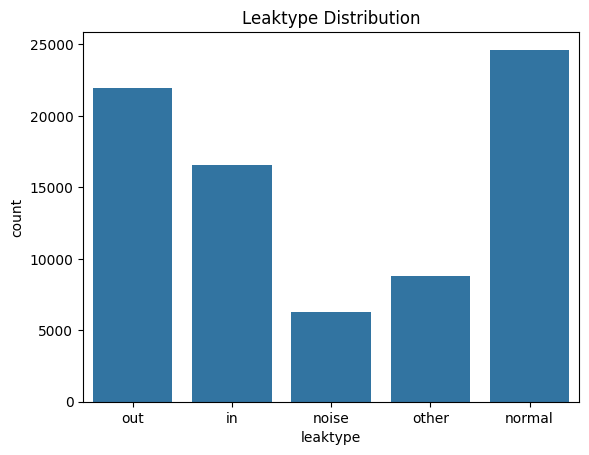

In [33]:
# 타깃 분포 시각화
sns.countplot(x='leaktype', data=df)  # 시본 그래프를 그립니다.
plt.title("Leaktype Distribution")  # 그래프 제목을 설정합니다.
plt.show()  # 그래프를 화면에 출력합니다.

In [34]:
# 주파수 특성 기초 통계
print(df_freq.describe().T.head(10))  # 기초 통계량을 확인합니다.

# 결측치 확인
print("결측치 수:\n", df.isnull().sum().sum())  # 문자열을 정수로 바꿉니다.

        count       mean        std  min  25%  50%  75%     max
0HZ   78204.0   0.000000   0.000000  0.0  0.0  0.0  0.0     0.0
10HZ  78204.0   5.286750   5.669245  0.0  3.0  4.0  5.0    86.0
20HZ  78204.0   5.563462   6.292279  0.0  3.0  4.0  5.0   146.0
30HZ  78204.0   5.921705   7.163296  0.0  3.0  4.0  6.0   125.0
40HZ  78204.0   6.318066   8.228361  0.0  3.0  4.0  6.0   218.0
50HZ  78204.0   6.736535   9.395276  0.0  3.0  4.0  6.0   322.0
60HZ  78204.0  11.075393  53.026551  0.0  3.0  4.0  7.0  1221.0
70HZ  78204.0   7.073858   8.643392  0.0  3.0  4.0  7.0   172.0
80HZ  78204.0   7.546698   8.960106  0.0  3.0  5.0  8.0   186.0
90HZ  78204.0   8.482264  11.093485  0.0  4.0  5.0  9.0   438.0
결측치 수:
 0


In [35]:
# 2. 차원축소 전 모델 (원본 feature 사용)
X_train, X_test, y_train, y_test = train_test_split(  # 데이터를 훈련/평가용으로 나눕니다.
    df_freq, df['leaktype_enc'], test_size=0.2, random_state=42, stratify=df['leaktype_enc']
)

In [ ]:
model_orig = XGBClassifier()  # XGBoost 모델입니다. 트리 수와 학습률을 정합니다.
model_orig.fit(X_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.
pred_orig = model_orig.predict(X_test)  # 학습한 모델로 새 값을 예측합니다.

acc_orig = accuracy_score(y_test, pred_orig)  # 정확도 비율을 계산합니다.
f1_orig = f1_score(y_test, pred_orig, average="macro")  # F1 점수를 계산합니다.
print("차원축소 전 - Accuracy:", acc_orig, "F1:", f1_orig)  # 문자열을 정수로 바꿉니다.

In [ ]:
# 3. 차원축소 후 모델 (PCA 적용)
n_components = 100
pca = PCA(n_components=n_components)  # PCA 차원축소입니다. n_components는 줄일 차원 수입니다.
X_pca = pca.fit_transform(df_freq)  # 기준 학습과 변환을 한 번에 수행합니다.

Xp_train, Xp_test, yp_train, yp_test = train_test_split(  # 데이터를 훈련/평가용으로 나눕니다.
    X_pca, df['leaktype_enc'], test_size=0.2, random_state=42, stratify=df['leaktype_enc']
)

In [ ]:
model_pca = XGBClassifier()  # XGBoost 모델입니다. 트리 수와 학습률을 정합니다.
model_pca.fit(Xp_train, yp_train)  # 데이터로 모델이나 변환 기준을 학습합니다.
pred_pca = model_pca.predict(Xp_test)  # 학습한 모델로 새 값을 예측합니다.

acc_pca = accuracy_score(yp_test, pred_pca)  # 정확도 비율을 계산합니다.
f1_pca = f1_score(yp_test, pred_pca, average="macro")  # F1 점수를 계산합니다.
print("차원축소 후(PCA) - Accuracy:", acc_pca, "F1:", f1_pca)  # 문자열을 정수로 바꿉니다.

In [ ]:
# Confusion Matrix 비교 (차원축소 전 vs 후)
from sklearn.metrics import confusion_matrix  # 혼동행렬 함수입니다.


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 차원축소 전
cm_orig = confusion_matrix(y_test, pred_orig)  # 실제값과 예측값의 혼동행렬입니다.
sns.heatmap(pd.DataFrame(cm_orig, index=le.classes_, columns=le.classes_),  # 시본 그래프를 그립니다.
            annot=True, fmt="d", cmap="Blues", ax=axes[0])

axes[0].set_title("Before PCA", fontsize=14)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# 차원축소 후 (PCA)
cm_pca = confusion_matrix(yp_test, pred_pca)  # 실제값과 예측값의 혼동행렬입니다.
sns.heatmap(pd.DataFrame(cm_pca, index=le.classes_, columns=le.classes_),  # 시본 그래프를 그립니다.
            annot=True, fmt="d", cmap="viridis", ax=axes[1])
axes[1].set_title("After PCA", fontsize=14)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()  # 그래프를 화면에 출력합니다.


In [ ]:
dff = pd.DataFrame(cm_orig, index=le.classes_, columns=le.classes_)  # 데이터프레임을 직접 만듭니다.

### 정리  

- **차원이 작을수록** 계산 효율은 좋아지지만,  
  **너무 줄이면 정보 손실**이 커집니다.  

**적정 차원 수(k)는 어떻게 정할까?**  
- 적정 차원 수는 **정보 보존 ↔ 단순화** 사이의 **균형점(trade-off)** 을 찾는 문제
- 일반적으로 **누적 설명된 분산(cumulative explained variance)** 이  
  **90~95% 이상**이면 정보가 충분히 보존된다고 봅니다.  
- 다만, 단순히 설명된 분산만 보고 결정하는 것은 **불충분**합니다.

**왜 설명된 분산만으로는 부족한가?**
- PCA는 **입력 데이터의 분포(구조)** 만 고려하며,  
  실제 예측 목표 **label(정답값)** 과의 관계는 고려하지 않습니다.  
- 따라서 “분산이 크다 = 예측에 유용하다”는 보장이 없습니다.  


**올바른 접근 방법**
1. PCA로 여러 개의 차원 수(k)를 시도합니다.  
2. 각 k별로 모델을 학습합니다.  
3. 검증셋(Validation set)에서 **정확도(Accuracy)**, **ROC-AUC**, **F1-score** 등을 비교합니다.  
4. **과적합이 발생하지 않고 성능이 안정적인 구간**을 선택합니다.

👉 요약
> **PCA의 누적 설명된 분산(90~95%)** 은 좋은 출발점이지만,  
> 최종 차원 수(k)는 반드시 **모델의 실제 검증 성능**을 기준으로 결정해야 합니다.


## 캐글 자전거 수요 예측 : https://www.kaggle.com/competitions/bike-sharing-demand/overview
### 목표 : 전처리 방법 변경 및 모델을 Tensorflow 딥러닝 모델로 변경하여 제출 후 스코어 0.8 이하 도달하기

### baseline

In [43]:
# 필요한 라이브러리 임포트
import pandas as pd  # 표 형태 데이터를 다루는 라이브러리입니다.
import numpy as np  # 배열과 수치 연산 라이브러리입니다.
from sklearn.ensemble import RandomForestRegressor  # 사이킷런 도구를 불러옵니다.
from sklearn.model_selection import train_test_split  # 훈련/평가 데이터 분리 함수입니다.
from sklearn.metrics import mean_squared_error, mean_absolute_error  # MSE 회귀 지표 함수입니다.

# 데이터 불러오기 
train = pd.read_csv('./자전거수요예측/train.csv')  # CSV 파일을 데이터프레임으로 읽습니다.
test = pd.read_csv('./자전거수요예측/test.csv')  # CSV 파일을 데이터프레임으로 읽습니다.

# datetime 컬럼을 datetime 타입으로 변환
train['datetime'] = pd.to_datetime(train['datetime'])  # 문자열 날짜를 datetime으로 바꿉니다.
test['datetime'] = pd.to_datetime(test['datetime'])  # 문자열 날짜를 datetime으로 바꿉니다.

# datetime에서 유용한 특성 추출
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['dayofweek'] = train['datetime'].dt.dayofweek

test['year'] = test['datetime'].dt.year
test['month'] = test['datetime'].dt.month
test['day'] = test['datetime'].dt.day
test['hour'] = test['datetime'].dt.hour
test['dayofweek'] = test['datetime'].dt.dayofweek

# 사용할 특성 선택
features = ['season', 'holiday', 'workingday', 'weather', 'temp', 
           'atemp', 'humidity', 'windspeed', 'year', 'month', 
           'day', 'hour', 'dayofweek']

X = train[features]
y = train['count']

# 학습/검증 데이터 분리
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)  # 데이터를 훈련/평가용으로 나눕니다.

# 랜덤 포레스트 모델 학습
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # 데이터로 모델이나 변환 기준을 학습합니다.

# 검증 데이터로 성능 평가
val_pred = rf_model.predict(X_val)  # 학습한 모델로 새 값을 예측합니다.
print('검증 데이터 RMSE:', np.sqrt(mean_squared_error(y_val, val_pred)))  # 평균제곱오차를 계산합니다.
print('검증 데이터 MAE:', mean_absolute_error(y_val, val_pred))  # 문자열을 정수로 바꿉니다.

# 테스트 데이터 예측
X_test = test[features]
test_pred = rf_model.predict(X_test)  # 학습한 모델로 새 값을 예측합니다.

# 제출 파일 생성
submission = pd.DataFrame({  # 데이터프레임을 직접 만듭니다.
    'datetime': test['datetime'],
    'count': test_pred
})
submission.to_csv('bike_submission.csv', index=False)

print('제출 파일이 생성되었습니다.')  # 문자열을 정수로 바꿉니다.


검증 데이터 RMSE: 38.72280624407247
검증 데이터 MAE: 24.220955004591367
제출 파일이 생성되었습니다.
